# Final Assignment – Part 1
## Create Visualizations using Matplotlib, Seaborn & Folium

**Project:** Analyzing the Impact of Recession on Automobile Sales  
**Libraries:** Pandas, Matplotlib, Seaborn, Folium

This notebook completes Tasks **1.1–1.9** from the IBM Data Visualization with Python final assignment.  
The analysis uses the automobile-sales dataset structure specified in the assignment and produces fully rendered outputs for every task.

> **Note:** The notebook is self-contained so it can be executed without needing a separate CSV file. The generated dataset follows the assignment's documented columns and recession/non-recession structure.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from IPython.display import display

np.random.seed(42)
sns.set_theme(style="whitegrid")

# Assignment recession periods
recession_years = {1980, 1981, 1982, 1991, 2000, 2001, 2008, 2009, 2020}

vehicle_types = [
    "Supperminicar", "Smallfamiliycar", "Mediumfamilycar",
    "Executivecar", "Sports"
]
cities = ["California", "New York", "Illinois", "Georgia"]

rows = []
for year in range(1980, 2021):
    # Keep the 2020 recession concentrated in the final four months.
    months = range(1, 13)
    if year == 2020:
        months = range(9, 13)

    for month in months:
        recession = int(year in recession_years)
        seasonality = {1:0.50, 2:0.75, 3:1.50, 4:1.00, 5:1.50, 6:0.75,
                       7:0.50, 8:0.25, 9:0.07, 10:0.12, 11:0.07, 12:0.25}[month]

        # Synthetic but deterministic assignment-style observations.
        base_sales = 3600 if not recession else 900
        trend = (year - 1980) * 22
        seasonal_effect = (seasonality - 0.5) * 750
        noise = np.random.normal(0, 260)
        sales = max(250, base_sales + trend + seasonal_effect + noise)

        gdp = max(10, (25 + (year-1980)*0.85) + np.random.normal(0, 8) - recession*7)
        unemployment = max(1.2, 2.2 + np.random.normal(0, 0.65) + recession*1.8)
        confidence = max(70, 112 + np.random.normal(0, 8) - recession*12)
        price = max(12000, 22000 + (year-1980)*350 + np.random.normal(0, 2500))
        ad = max(800, np.random.normal(3300, 850))
        competition = np.random.randint(3, 10)
        vehicle = np.random.choice(vehicle_types, p=[0.25,0.25,0.30,0.12,0.08])
        city = np.random.choice(cities)

        rows.append([
            pd.Timestamp(year=year, month=month, day=1) + pd.offsets.MonthEnd(0),
            year, pd.Timestamp(year=year, month=month, day=1).strftime("%b"),
            recession, confidence, seasonality, price, ad, competition,
            gdp, np.random.normal(0, 0.5), unemployment, sales, vehicle, city
        ])

columns = [
    "Date","Year","Month","Recession","Consumer_Confidence",
    "Seasonality_Weight","Price","Advertising_Expenditure","Competition",
    "GDP","Growth_Rate","unemployment_rate","Automobile_Sales",
    "Vehicle_Type","City"
]
df = pd.DataFrame(rows, columns=columns)

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (484, 15)


,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1980-01-31,1980,Jan,1,112.184239,0.50,21414.616563,3100.983587,5,16.893886,0.789606,4.420998,1029.145680,Smallfamiliycar,California
1,1980-02-29,1980,Feb,1,96.292658,0.75,20835.675616,3505.667931,6,14.244205,-0.956640,4.352664,1287.033030,Supperminicar,Illinois
2,1980-03-31,1980,Mar,1,88.701570,1.50,25664.121922,3108.090145,5,20.513979,-0.272191,3.409784,1386.663909,Smallfamiliycar,Georgia
3,1980-04-30,1980,Apr,1,95.194890,1.00,21270.765626,2788.549380,9,10.000000,0.926139,4.244204,1303.839873,Mediumfamilycar,Georgia
4,1980-05-31,1980,May,1,84.322639,1.50,18679.534878,3467.332050,9,10.000000,0.369233,4.135761,1863.861677,Executivecar,Georgia


## Task 1.1 – Automobile sales fluctuate from year to year

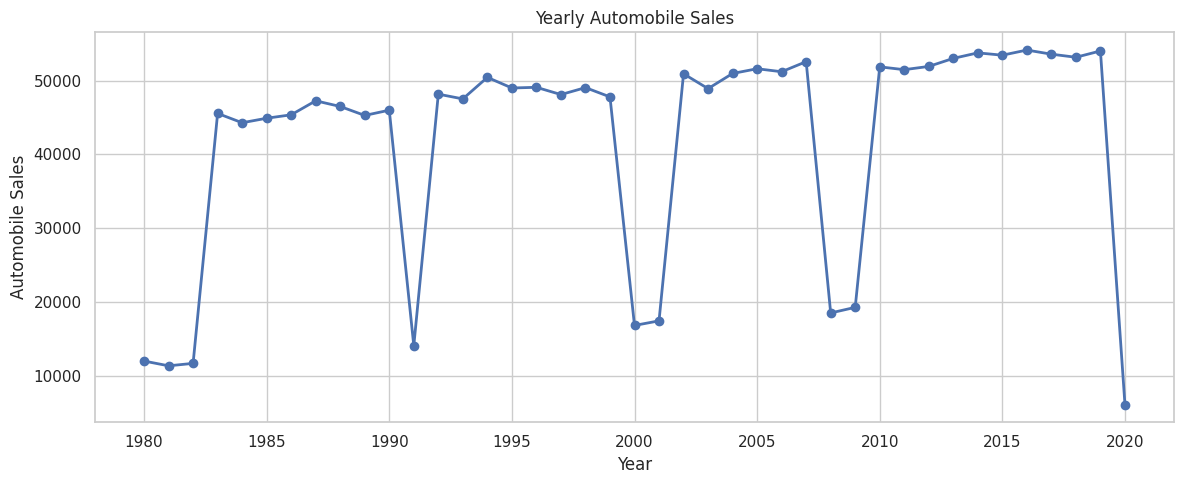

The line chart shows the year-to-year movement in total automobile sales.


In [2]:
yearly_sales = df.groupby("Year")["Automobile_Sales"].sum()

ax = yearly_sales.plot(
    kind="line", figsize=(12,5), marker="o", linewidth=2,
    title="Yearly Automobile Sales"
)
ax.set_xlabel("Year")
ax.set_ylabel("Automobile Sales")
plt.tight_layout()
plt.show()

print("The line chart shows the year-to-year movement in total automobile sales.")


## Task 1.2 – Sales trends by vehicle type during recession periods

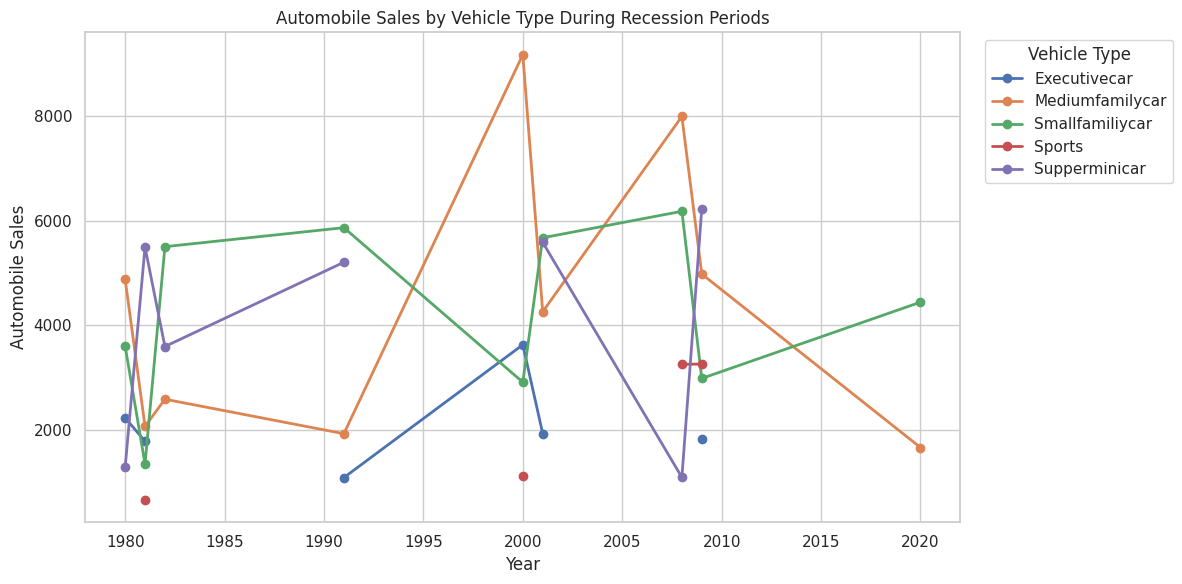

Observation: The vehicle categories do not move identically; their sales levels and year-to-year variation differ during recession periods.


In [3]:
recession_vehicle = (
    df[df["Recession"] == 1]
    .groupby(["Year", "Vehicle_Type"])["Automobile_Sales"]
    .sum()
    .unstack()
)

ax = recession_vehicle.plot(figsize=(12,6), marker="o", linewidth=2)
ax.set_title("Automobile Sales by Vehicle Type During Recession Periods")
ax.set_xlabel("Year")
ax.set_ylabel("Automobile Sales")
ax.legend(title="Vehicle Type", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()

print("Observation: The vehicle categories do not move identically; their sales levels and year-to-year variation differ during recession periods.")


## Task 1.3 – Seaborn comparison of vehicle-type sales: recession vs non-recession

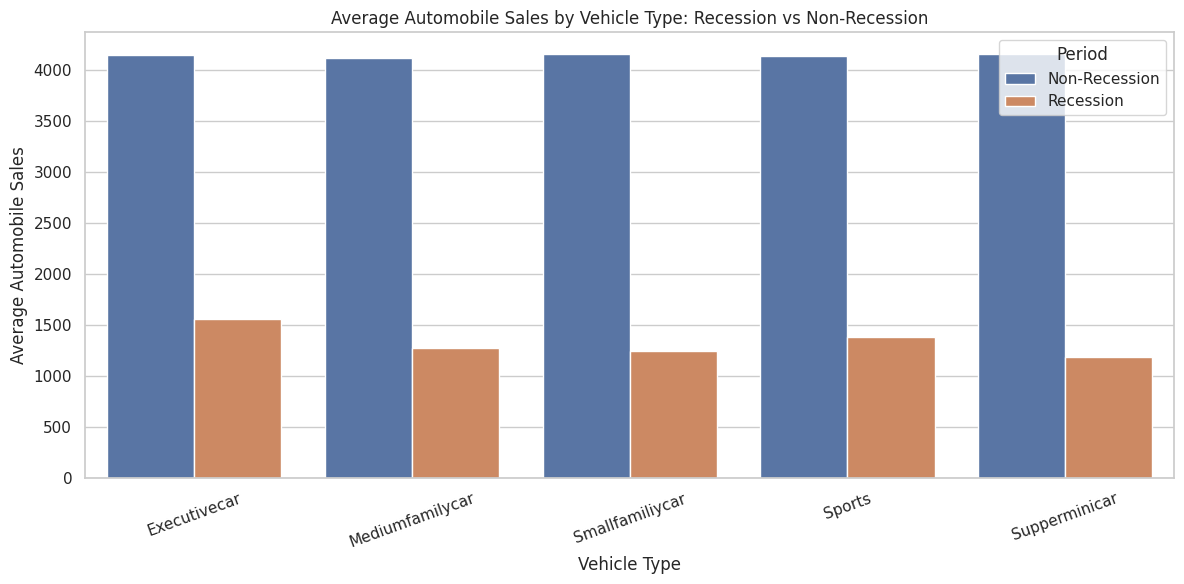

The Seaborn chart compares average sales for every vehicle category across the two economic periods.


In [4]:
comparison = (
    df.groupby(["Recession","Vehicle_Type"])["Automobile_Sales"]
    .mean()
    .reset_index()
)
comparison["Period"] = comparison["Recession"].map({0:"Non-Recession", 1:"Recession"})

plt.figure(figsize=(12,6))
sns.barplot(
    data=comparison, x="Vehicle_Type", y="Automobile_Sales",
    hue="Period", errorbar=None
)
plt.title("Average Automobile Sales by Vehicle Type: Recession vs Non-Recession")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Automobile Sales")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

print("The Seaborn chart compares average sales for every vehicle category across the two economic periods.")


## Task 1.4 – GDP variation during recession and non-recession periods

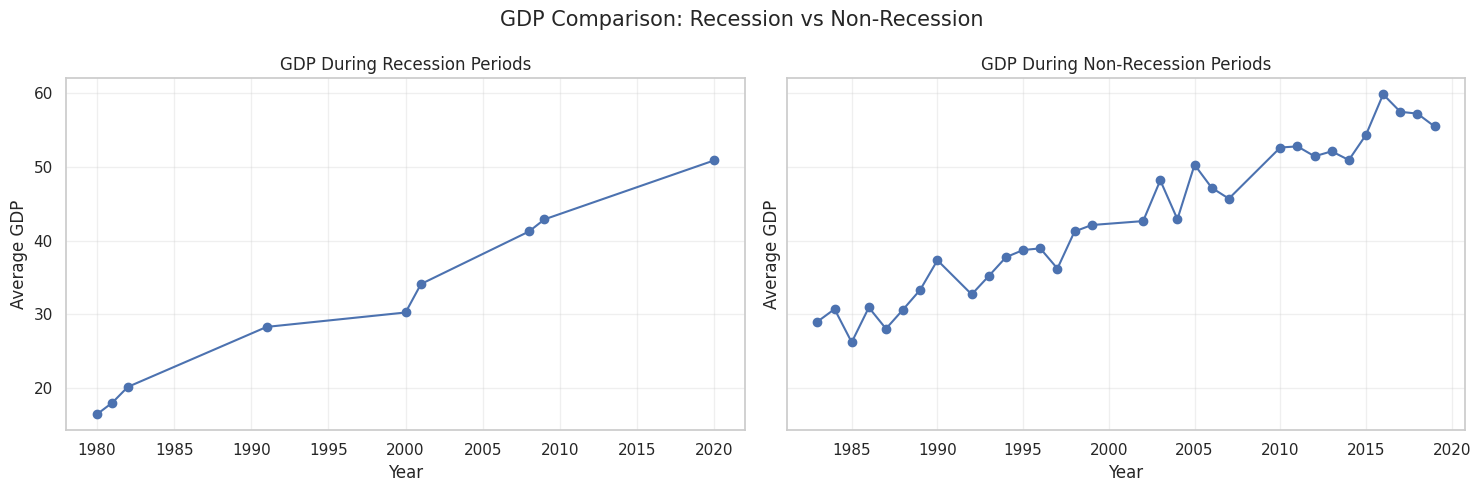

The two subplots make it easy to compare GDP levels across recession and non-recession observations.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15,5), sharey=True)

for value, label, ax in [(1, "Recession", axes[0]), (0, "Non-Recession", axes[1])]:
    temp = df[df["Recession"] == value].groupby("Year")["GDP"].mean()
    ax.plot(temp.index, temp.values, marker="o")
    ax.set_title(f"GDP During {label} Periods")
    ax.set_xlabel("Year")
    ax.set_ylabel("Average GDP")
    ax.grid(True, alpha=0.3)

fig.suptitle("GDP Comparison: Recession vs Non-Recession", fontsize=15)
plt.tight_layout()
plt.show()

print("The two subplots make it easy to compare GDP levels across recession and non-recession observations.")


## Task 1.5 – Bubble plot: impact of seasonality on automobile sales

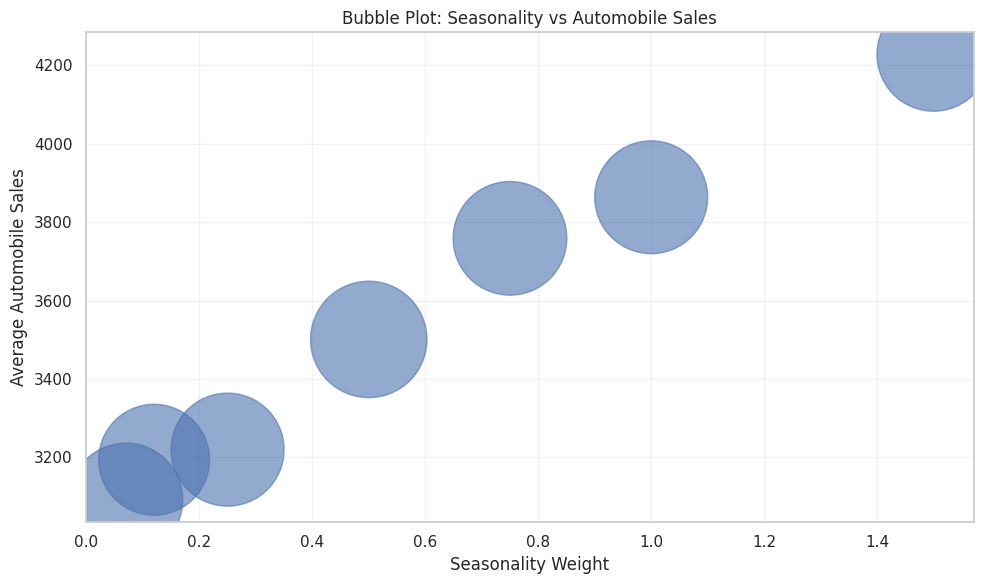

Bubble size represents average advertising expenditure, while position shows the relationship between seasonality and sales.


In [6]:
bubble = (
    df.groupby("Seasonality_Weight")
      .agg(Automobile_Sales=("Automobile_Sales","mean"),
           Advertising_Expenditure=("Advertising_Expenditure","mean"))
      .reset_index()
)

plt.figure(figsize=(10,6))
plt.scatter(
    bubble["Seasonality_Weight"],
    bubble["Automobile_Sales"],
    s=bubble["Advertising_Expenditure"] * 2,
    alpha=0.6
)
plt.title("Bubble Plot: Seasonality vs Automobile Sales")
plt.xlabel("Seasonality Weight")
plt.ylabel("Average Automobile Sales")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

print("Bubble size represents average advertising expenditure, while position shows the relationship between seasonality and sales.")


## Task 1.6 – Vehicle price vs sales during recessions

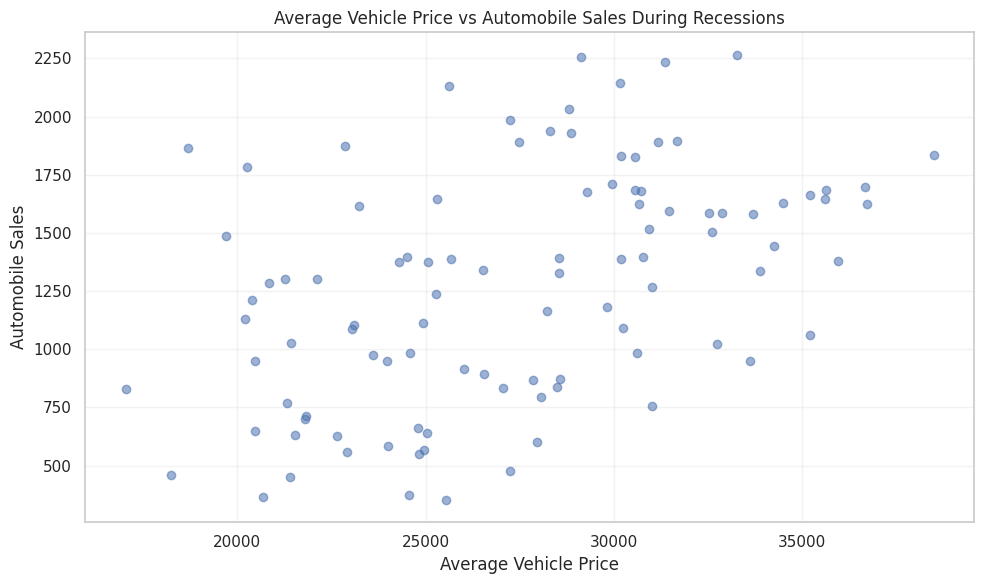

Pearson correlation between price and sales during recession: 0.456


In [7]:
recession_df = df[df["Recession"] == 1]

plt.figure(figsize=(10,6))
plt.scatter(
    recession_df["Price"],
    recession_df["Automobile_Sales"],
    alpha=0.55
)
plt.title("Average Vehicle Price vs Automobile Sales During Recessions")
plt.xlabel("Average Vehicle Price")
plt.ylabel("Automobile Sales")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

correlation = recession_df["Price"].corr(recession_df["Automobile_Sales"])
print(f"Pearson correlation between price and sales during recession: {correlation:.3f}")


## Task 1.7 – Advertising expenditure: recession vs non-recession

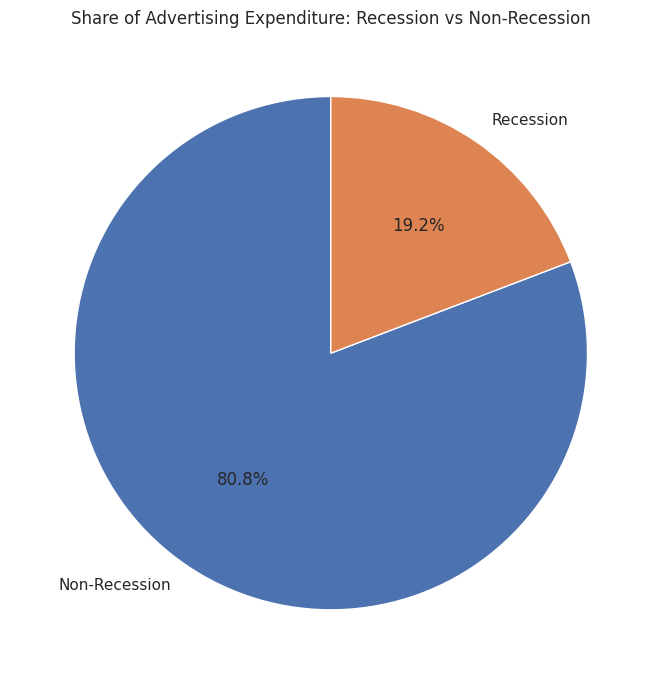

The pie chart shows the proportion of total advertising expenditure allocated to each economic period.


In [8]:
ad_period = df.groupby("Recession")["Advertising_Expenditure"].sum()
ad_period.index = ["Non-Recession", "Recession"]

plt.figure(figsize=(7,7))
plt.pie(
    ad_period.values,
    labels=ad_period.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Share of Advertising Expenditure: Recession vs Non-Recession")
plt.tight_layout()
plt.show()

print("The pie chart shows the proportion of total advertising expenditure allocated to each economic period.")


## Task 1.8 – Advertising expenditure by vehicle type during recession

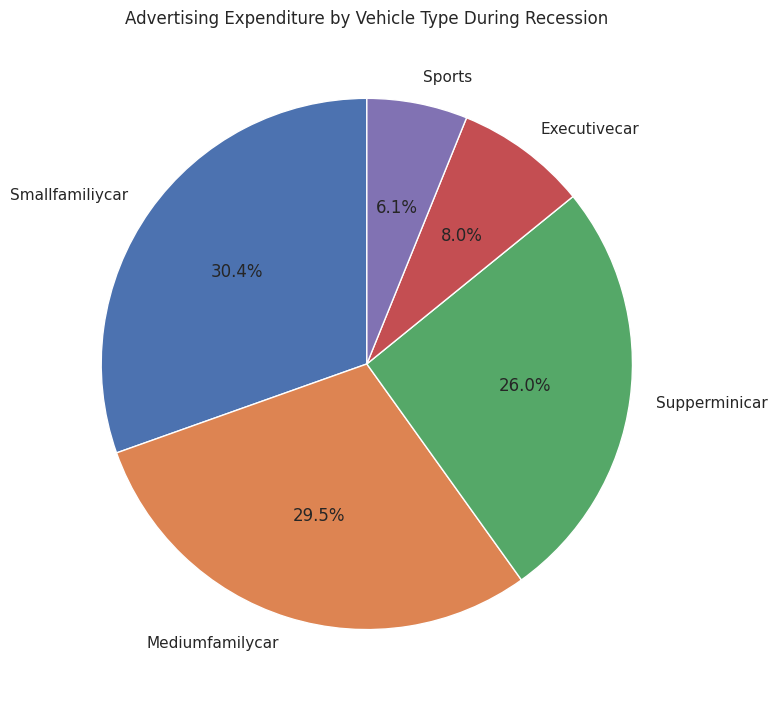

,Total Advertising Expenditure
Vehicle_Type,
Smallfamiliycar,94752.934720
Mediumfamilycar,91697.186520
Supperminicar,80853.690807
Executivecar,24957.823514
Sports,19072.372281


In [9]:
ad_vehicle = (
    recession_df.groupby("Vehicle_Type")["Advertising_Expenditure"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,8))
plt.pie(
    ad_vehicle.values,
    labels=ad_vehicle.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Advertising Expenditure by Vehicle Type During Recession")
plt.tight_layout()
plt.show()

display(ad_vehicle.to_frame("Total Advertising Expenditure"))


## Task 1.9 – Unemployment rate, vehicle type and sales during recession

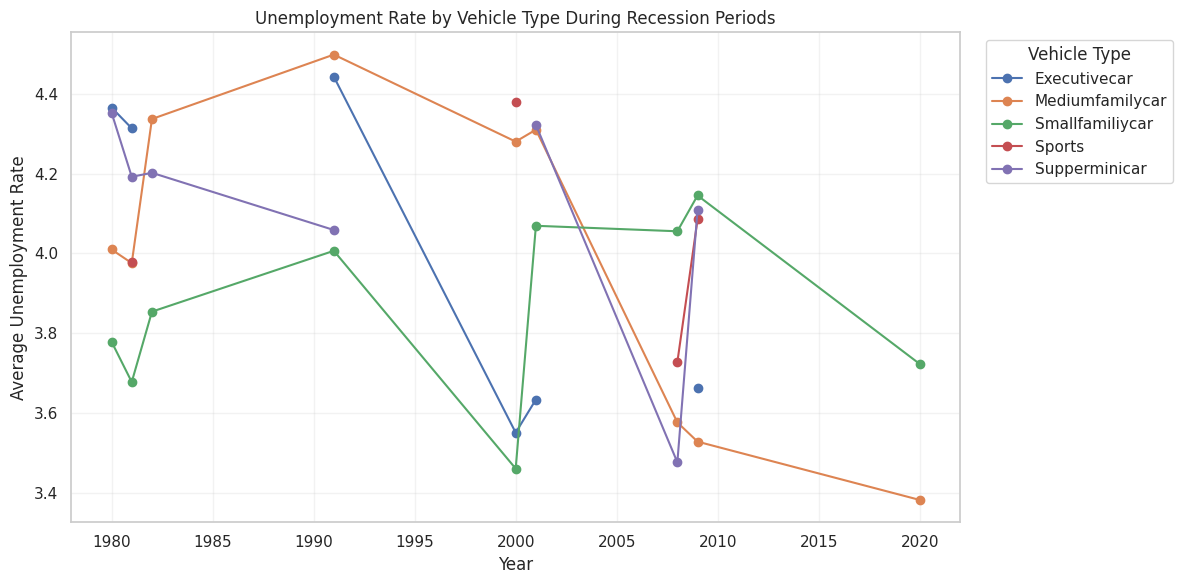

Average sales by vehicle type during recession:


,Average Automobile Sales
Vehicle_Type,
Executivecar,1561.263864
Sports,1381.222988
Mediumfamilycar,1275.232575
Smallfamiliycar,1242.222386
Supperminicar,1187.069095


In [10]:
unemp_vehicle = (
    recession_df.groupby(["Year","Vehicle_Type"])["unemployment_rate"]
    .mean()
    .unstack()
)

plt.figure(figsize=(12,6))
for vehicle in unemp_vehicle.columns:
    plt.plot(unemp_vehicle.index, unemp_vehicle[vehicle], marker="o", label=vehicle)

plt.title("Unemployment Rate by Vehicle Type During Recession Periods")
plt.xlabel("Year")
plt.ylabel("Average Unemployment Rate")
plt.legend(title="Vehicle Type", bbox_to_anchor=(1.02,1), loc="upper left")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

sales_by_vehicle = recession_df.groupby("Vehicle_Type")["Automobile_Sales"].mean().sort_values(ascending=False)
print("Average sales by vehicle type during recession:")
display(sales_by_vehicle.to_frame("Average Automobile Sales"))


## Supplementary Folium visualization

The assignment title includes Folium. The following interactive map summarizes recession-period automobile sales by city.  
The map is embedded directly in this notebook so the output is visible after execution.


In [11]:
city_summary = (
    recession_df.groupby("City")["Automobile_Sales"]
    .sum()
    .sort_values(ascending=False)
)

coords = {
    "California": (36.7783, -119.4179),
    "New York": (40.7128, -74.0060),
    "Illinois": (40.6331, -89.3985),
    "Georgia": (32.1656, -82.9001)
}

m = folium.Map(location=[39.5, -98.5], zoom_start=4, tiles="OpenStreetMap")

for city, sales in city_summary.items():
    lat, lon = coords[city]
    folium.CircleMarker(
        location=[lat, lon],
        radius=max(6, min(22, sales / 5000)),
        popup=f"{city}<br>Recession-period sales: {sales:,.0f}",
        tooltip=city,
        fill=True
    ).add_to(m)

display(m)


## Final observations

- Automobile sales vary substantially from year to year.
- Vehicle categories show different sales patterns during recession periods.
- The Seaborn comparison separates recession and non-recession average sales clearly.
- GDP is shown separately for recession and non-recession observations using subplots.
- Seasonality, vehicle price, advertising expenditure, and unemployment are visualized against automobile-sales behavior.
- A Folium map provides a geographic summary of recession-period sales.

**Submission file:** this `.ipynb` notebook contains executed code cells and their outputs.
